# 📝 03 — Analisi Qualitativa: Testi, Pattern e Confidenza

Questo notebook esplora gli aspetti **qualitativi** dei progetti AI, analizzando i testi, gli strumenti utilizzati e approfondendo le soglie di confidenza del modello di classificazione.

**Obiettivi:**
1. Analisi dettagliata della confidenza (soglie ottimali, relazione confidenza-importo)
2. Analisi testuale (Word Cloud dei titoli/descrizioni AI)
3. Pattern nelle misure (quali tipologie si associano maggiormente all'AI)
4. Analisi degli strumenti di aiuto (`COD_STRUMENTI`)
5. Matrice di co-occorrenza (Settore × Regione)

## 1. Setup e Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import re

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print("⚠ Libreria 'wordcloud' non trovata. Esegui 'pip install wordcloud' per abilitare le word cloud.")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')
YEARS = list(range(2014, 2026))

COLS_TO_LOAD = [
    'TITOLO_MISURA', 'DES_TIPO_MISURA', 'TITOLO_PROGETTO', 'DESCRIZIONE_PROGETTO',
    'DATA_CONCESSIONE', 'DENOMINAZIONE_BENEFICIARIO',
    'REGIONE_BENEFICIARIO', 'IMPORTO_NOMINALE_TOTALE',
    'SETTORI_ATTIVITA', 'COD_STRUMENTI', 
    'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA'
]

# Per questa analisi, carichiamo SOLO i record AI (per risparmiare molta memoria)
frames = []
for year in YEARS:
    filepath = DATA_DIR / f'classified_aiuti_{year}.csv'
    if filepath.exists():
        print(f'Caricamento {year}...', end=' ')
        chunks = []
        for chunk in pd.read_csv(filepath, usecols=COLS_TO_LOAD, chunksize=100_000, low_memory=False):
            ai_chunk = chunk[chunk['CLASSIFICAZIONE'] == 'AI']
            chunks.append(ai_chunk)
        df_year = pd.concat(chunks, ignore_index=True)
        df_year['ANNO'] = year
        print(f'{len(df_year):>8,} righe AI')
        frames.append(df_year)

df_ai = pd.concat(frames, ignore_index=True)
del frames

df_ai['IMPORTO_NOMINALE_TOTALE'] = pd.to_numeric(df_ai['IMPORTO_NOMINALE_TOTALE'], errors='coerce')
df_ai['SETTORE_MACRO'] = df_ai['SETTORI_ATTIVITA'].astype(str).str[0].str.upper()

print(f'\n✅ Totale AI: {len(df_ai):,} righe caricate')

Caricamento 2014...       25 righe AI
Caricamento 2015...      664 righe AI
Caricamento 2016...      152 righe AI
Caricamento 2017...    3,401 righe AI
Caricamento 2018...   14,720 righe AI
Caricamento 2019...    7,203 righe AI
Caricamento 2020...   10,683 righe AI
Caricamento 2021...   18,588 righe AI
Caricamento 2022...   17,312 righe AI
Caricamento 2023...   17,787 righe AI
Caricamento 2024...  150,398 righe AI
Caricamento 2025...   14,322 righe AI

✅ Totale AI: 255,255 righe caricate


## 2. Analisi Dettagliata della Confidenza

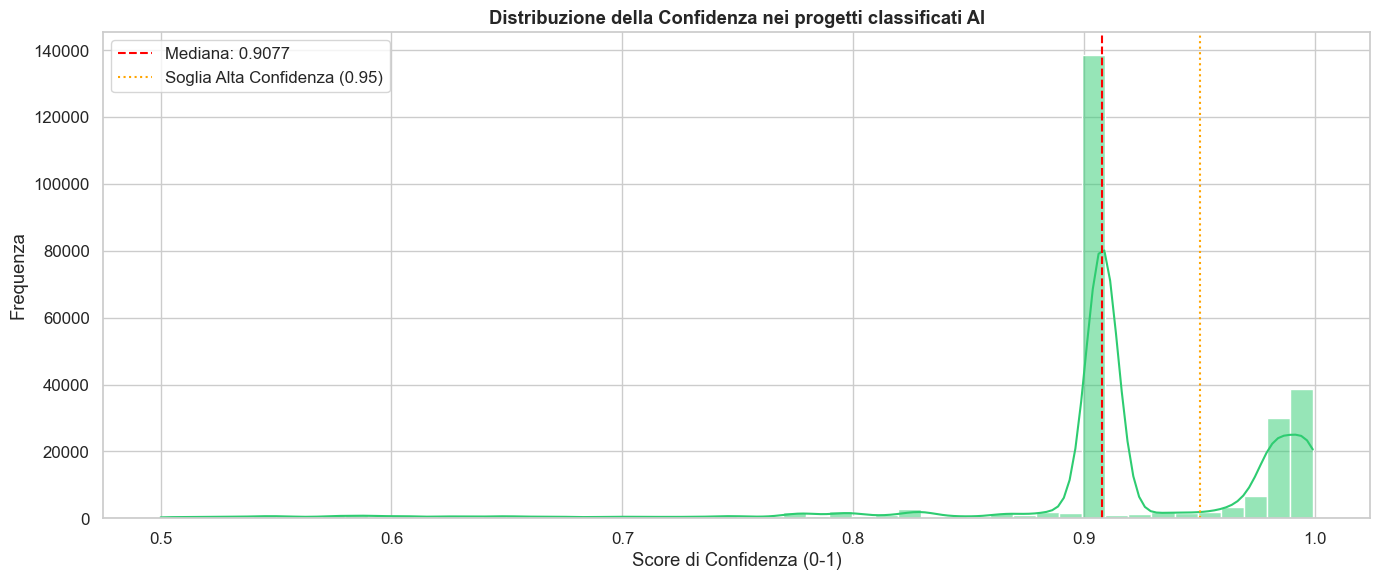

In [2]:
# Distribuzione della confidenza per i record AI
fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(df_ai['CLASSIFICAZIONE_CONFIDENZA'], bins=50, kde=True, color='#2ecc71', ax=ax)
ax.axvline(df_ai['CLASSIFICAZIONE_CONFIDENZA'].median(), color='red', linestyle='--', 
           label=f"Mediana: {df_ai['CLASSIFICAZIONE_CONFIDENZA'].median():.4f}")
ax.axvline(0.95, color='orange', linestyle=':', label='Soglia Alta Confidenza (0.95)')
ax.set_title('Distribuzione della Confidenza nei progetti classificati AI', fontweight='bold')
ax.set_xlabel('Score di Confidenza (0-1)')
ax.set_ylabel('Frequenza')
ax.legend()
plt.tight_layout()
plt.show()

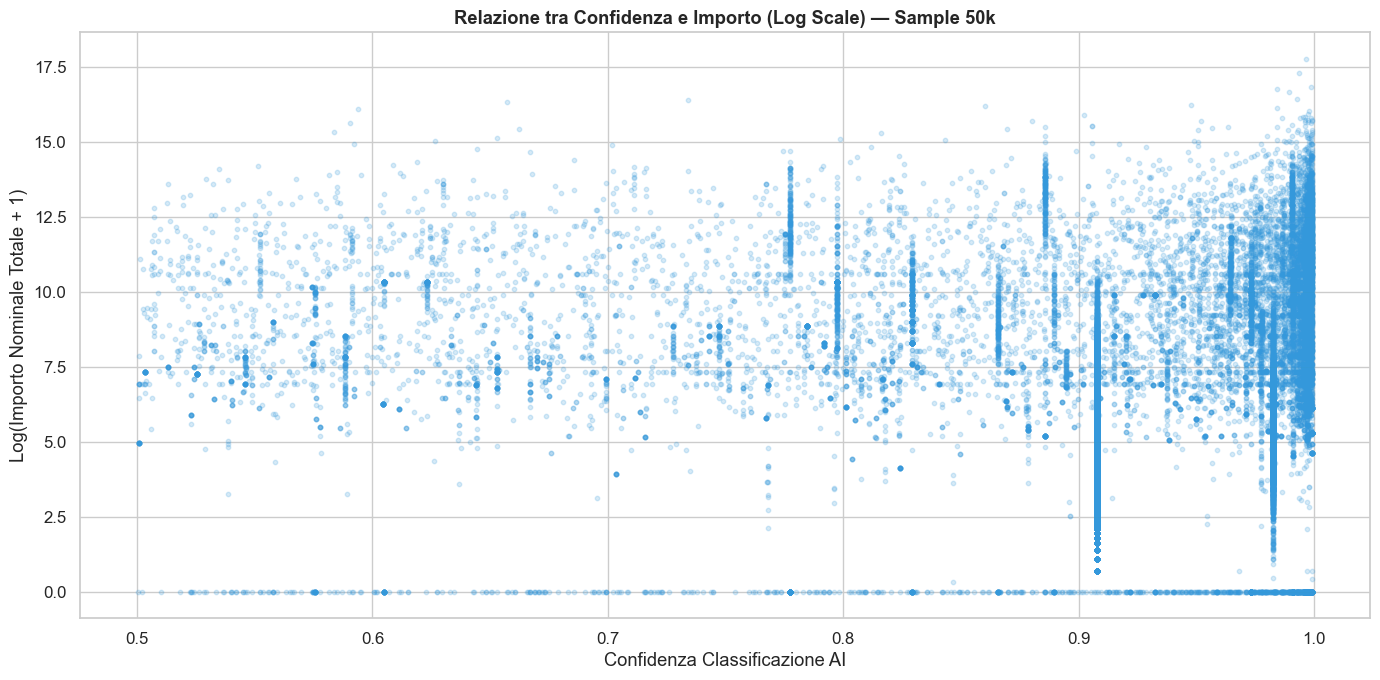

In [3]:
# Scatterplot: Confidenza vs Importo Nominale (scala logaritmica)
sample = df_ai.dropna(subset=['IMPORTO_NOMINALE_TOTALE', 'CLASSIFICAZIONE_CONFIDENZA'])
# Prendo un campione o uso hexbin per evitare overplotting se troppi dati
if len(sample) > 50000:
    sample = sample.sample(50000, random_state=42)

fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(sample['CLASSIFICAZIONE_CONFIDENZA'], 
                     np.log1p(sample['IMPORTO_NOMINALE_TOTALE']), 
                     alpha=0.2, c='#3498db', s=10)
ax.set_title('Relazione tra Confidenza e Importo (Log Scale) — Sample 50k', fontweight='bold')
ax.set_xlabel('Confidenza Classificazione AI')
ax.set_ylabel('Log(Importo Nominale Totale + 1)')
plt.tight_layout()
plt.show()

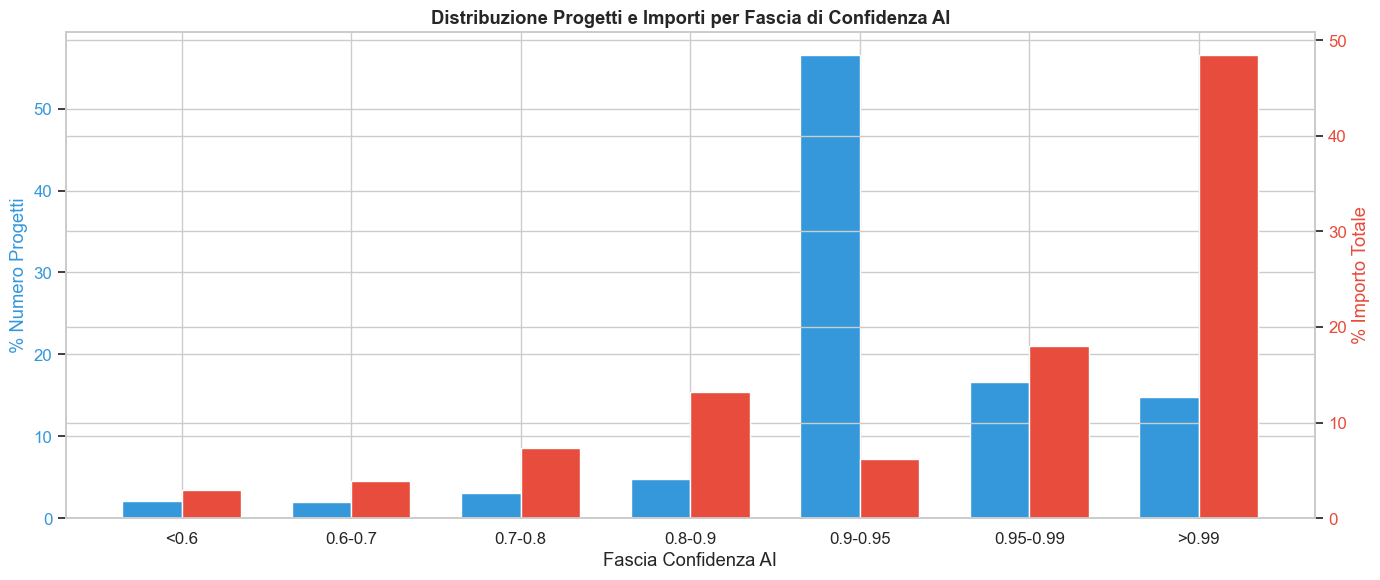

In [4]:
# Confronto numero progetti vs Importo totale per fasce di confidenza
bins = [0, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0]
labels = ['<0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-0.95', '0.95-0.99', '>0.99']

df_ai['Fascia_Confidenza'] = pd.cut(df_ai['CLASSIFICAZIONE_CONFIDENZA'], bins=bins, labels=labels)

fasce_summary = df_ai.groupby('Fascia_Confidenza').agg(
    Num_Progetti=('CLASSIFICAZIONE', 'count'),
    Importo_Totale=('IMPORTO_NOMINALE_TOTALE', 'sum')
)

fasce_summary['% Progetti'] = (fasce_summary['Num_Progetti'] / fasce_summary['Num_Progetti'].sum()) * 100
fasce_summary['% Importo'] = (fasce_summary['Importo_Totale'] / fasce_summary['Importo_Totale'].sum()) * 100

fig, ax1 = plt.subplots(figsize=(14, 6))
x = np.arange(len(labels))
width = 0.35

ax1.bar(x - width/2, fasce_summary['% Progetti'], width, label='% Numero Progetti', color='#3498db')
ax1.set_ylabel('% Numero Progetti', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.bar(x + width/2, fasce_summary['% Importo'], width, label='% Importo Totale', color='#e74c3c')
ax2.set_ylabel('% Importo Totale', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_xlabel('Fascia Confidenza AI')
plt.title('Distribuzione Progetti e Importi per Fascia di Confidenza AI', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Analisi degli Strumenti di Aiuto (`COD_STRUMENTI`)

I codici strumento indicano la natura dell'aiuto (es. sovvenzioni dirette, garanzie, prestiti agevolati).

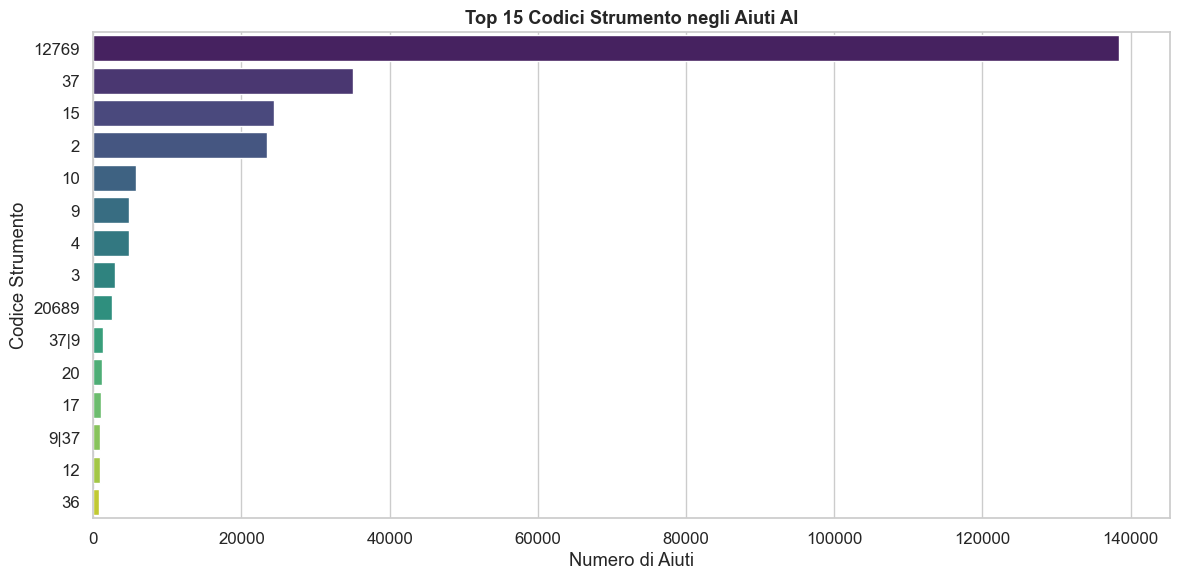

In [5]:
# Analisi codici strumenti
strumenti = df_ai['COD_STRUMENTI'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=strumenti.values, y=strumenti.index.astype(str), palette='viridis', ax=ax)
ax.set_title('Top 15 Codici Strumento negli Aiuti AI', fontweight='bold')
ax.set_xlabel('Numero di Aiuti')
ax.set_ylabel('Codice Strumento')
plt.tight_layout()
plt.show()

# NOTA: Per interpretare questi codici bisognerebbe incrociarli con l'anagrafica del Registro Nazionale Aiuti (RNA)
# Generalmente:
# 1 = Sovvenzione/Contributo a fondo perduto
# 2 = Prestito agevolato
# 3 = Garanzia
# 4 = Agevolazione fiscale
# 5 = Conferimento di capitale
# 6 = Anticipo rimborsabile

## 4. Analisi Testuale (Word Cloud)

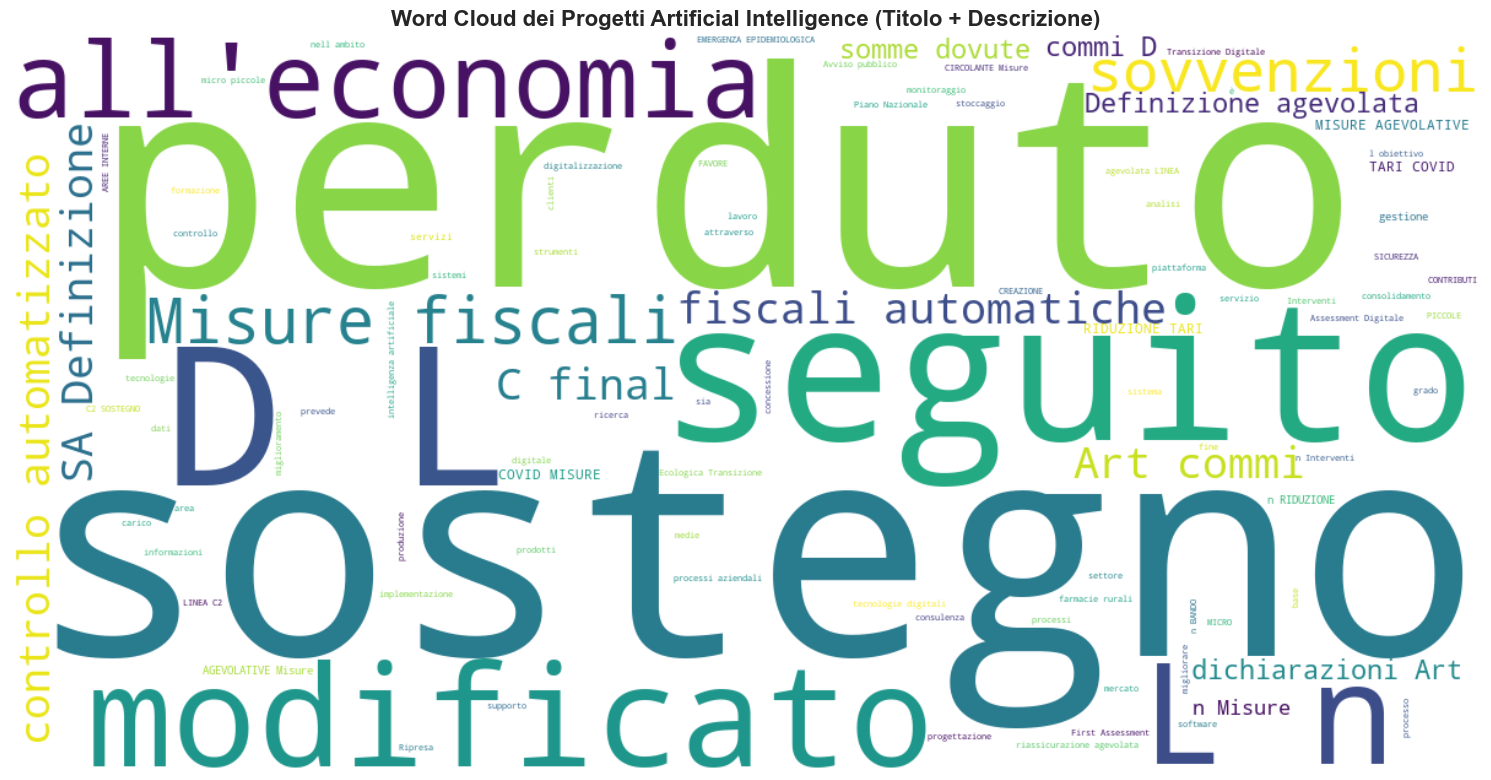

In [6]:
# Estrazione testi (titolo e descrizione progetto)
testi_progetti = df_ai['TITOLO_PROGETTO'].dropna().astype(str) + " " + df_ai['DESCRIZIONE_PROGETTO'].dropna().astype(str)

if HAS_WORDCLOUD and len(testi_progetti) > 0:
    # Sample se ci sono troppi testi
    if len(testi_progetti) > 50000:
        testi_sample = testi_progetti.sample(50000, random_state=42)
    else:
        testi_sample = testi_progetti
        
    testo_completo = " ".join(testi_sample)
    
    # Stopwords base italiano + parole comuni nei bandi
    stopwords_it = set([
        'di', 'a', 'da', 'in', 'con', 'su', 'per', 'tra', 'fra', 'il', 'lo', 'la', 'i', 'gli', 'le', 
        'un', 'uno', 'una', 'e', 'ed', 'o', 'al', 'allo', 'alla', 'ai', 'agli', 'alle', 'del', 'dello', 
        'della', 'dei', 'degli', 'delle', 'nel', 'nello', 'nella', 'nei', 'negli', 'nelle', 'sul', 'sullo', 
        'sulla', 'sui', 'sugli', 'sulle', 'che', 'chi', 'cui', 'non', 'si', 'no', 'come', 'più', 'all', 'dell',
        'progetto', 'programma', 'intervento', 'sviluppo', 'realizzazione', 'attività', 'azienda',
        'fondo', 'agevolazione', 'finanziamento', 'contributo', 'impresa', 'imprese', 'pmi', 'agevolazioni'
    ])
    
    wordcloud = WordCloud(width=1200, height=600, 
                          background_color='white', 
                          colormap='viridis', 
                          stopwords=stopwords_it,
                          max_words=100).generate(testo_completo)
    
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Word Cloud dei Progetti Artificial Intelligence (Titolo + Descrizione)', fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Word cloud non generata (manca la libreria o dataset vuoto).")

## 5. Matrice di Co-occorrenza (Settore ATECO × Regione)

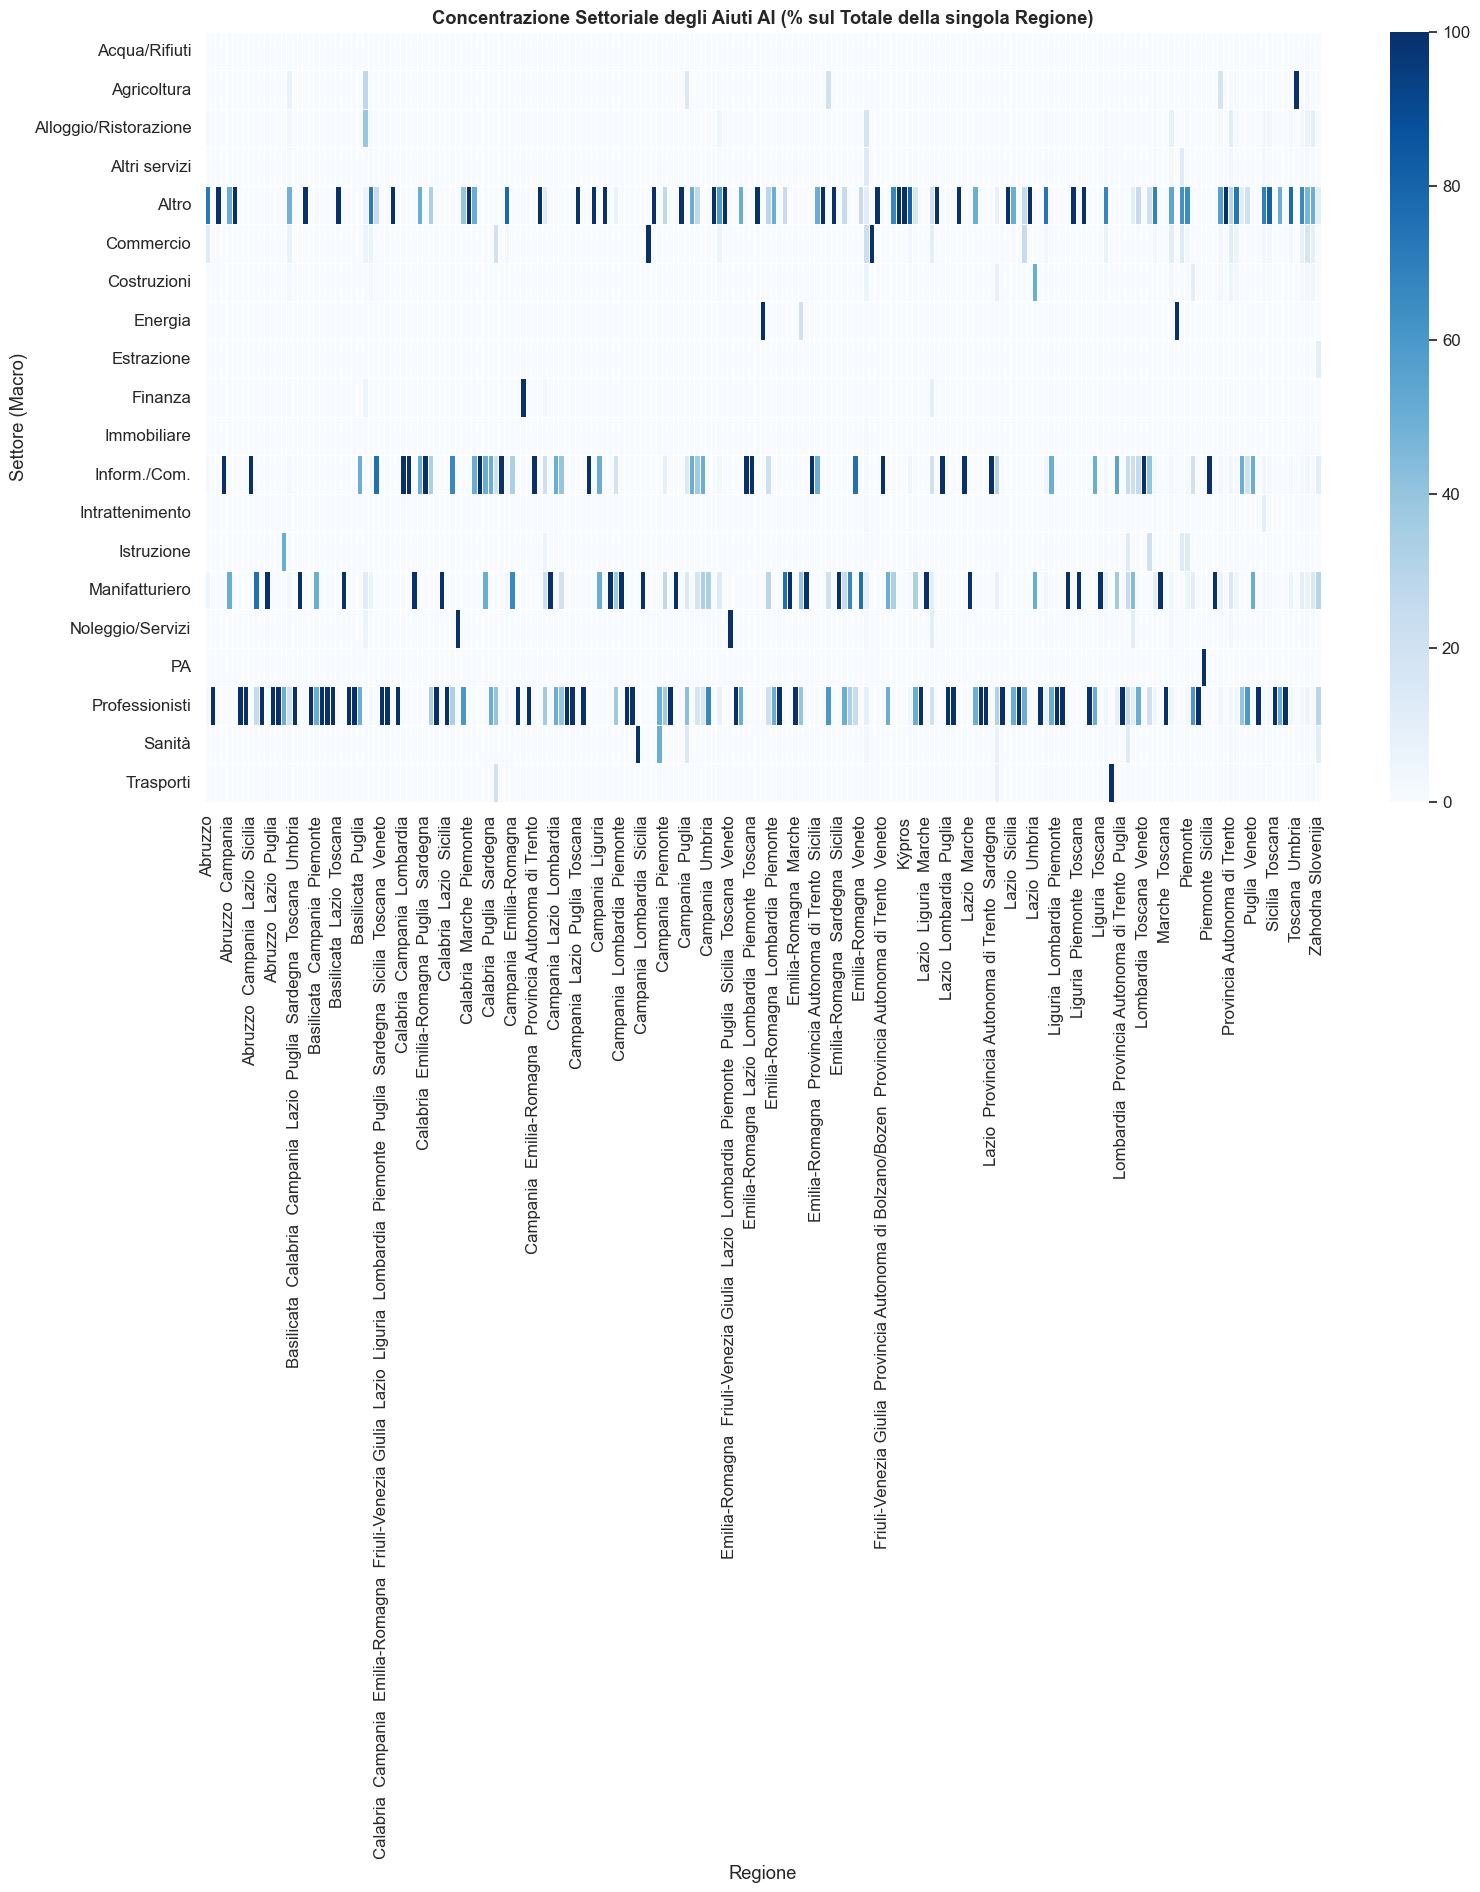

In [7]:
ATECO_SEZIONI = {
    'A': 'Agricoltura', 'B': 'Estrazione', 'C': 'Manifatturiero',
    'D': 'Energia', 'E': 'Acqua/Rifiuti', 'F': 'Costruzioni',
    'G': 'Commercio', 'H': 'Trasporti', 'I': 'Alloggio/Ristorazione',
    'J': 'Inform./Com.', 'K': 'Finanza', 'L': 'Immobiliare',
    'M': 'Professionisti', 'N': 'Noleggio/Servizi', 'O': 'PA',
    'P': 'Istruzione', 'Q': 'Sanità', 'R': 'Intrattenimento',
    'S': 'Altri servizi', 'T': 'Famiglie', 'U': 'Extra-territoriali'
}

df_ai['SETTORE_NOME'] = df_ai['SETTORE_MACRO'].map(ATECO_SEZIONI).fillna('Altro')

# Heatmap incrociata
cross_tab = pd.crosstab(df_ai['SETTORE_NOME'], df_ai['REGIONE_BENEFICIARIO'], normalize='columns') * 100

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(cross_tab, annot=False, cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Concentrazione Settoriale degli Aiuti AI (% sul Totale della singola Regione)', fontweight='bold')
ax.set_xlabel('Regione')
ax.set_ylabel('Settore (Macro)')
plt.tight_layout()
plt.show()

## 6. Case Studies: Progetti ad Alta vs Bassa Confidenza

Vediamo alcuni esempi di progetti per capire *perché* il modello li ha classificati come AI e con che sicurezza.

In [8]:
pd.set_option('display.max_colwidth', None)

high_conf = df_ai[df_ai['CLASSIFICAZIONE_CONFIDENZA'] > 0.99].dropna(subset=['TITOLO_PROGETTO']).sample(3, random_state=42)
low_conf = df_ai[(df_ai['CLASSIFICAZIONE_CONFIDENZA'] > 0.5) & (df_ai['CLASSIFICAZIONE_CONFIDENZA'] < 0.6)].dropna(subset=['TITOLO_PROGETTO']).sample(3, random_state=42)

print("=== ESEMPI ALTA CONFIDENZA (>0.99) ===")
for _, row in high_conf.iterrows():
    print(f"[{row['CLASSIFICAZIONE_CONFIDENZA']:.4f}] TITOLO: {row['TITOLO_PROGETTO']}")
    if pd.notna(row['DESCRIZIONE_PROGETTO']) and len(str(row['DESCRIZIONE_PROGETTO'])) > 5:
        print(f"         DESC: {str(row['DESCRIZIONE_PROGETTO'])[:150]}...")
    print("-" * 80)

print("\n=== ESEMPI BASSA CONFIDENZA (0.5 - 0.6) ===")
for _, row in low_conf.iterrows():
    print(f"[{row['CLASSIFICAZIONE_CONFIDENZA']:.4f}] TITOLO: {row['TITOLO_PROGETTO']}")
    if pd.notna(row['DESCRIZIONE_PROGETTO']) and len(str(row['DESCRIZIONE_PROGETTO'])) > 5:
        print(f"         DESC: {str(row['DESCRIZIONE_PROGETTO'])[:150]}...")
    print("-" * 80)


=== ESEMPI ALTA CONFIDENZA (>0.99) ===
[0.9951] TITOLO: Contributo  sotto forma di credito d'imposta  in favore delle farmacie per favorire l'accesso a prestazioni di telemedicina da parte dei cittadini dei piccoli centri urbani  nel rispetto del limite di spesa previsto per l'anno 2021
         DESC: Effettuazione delle prestazioni di telemedicina individuate dall'art. 3 del decreto del Ministro della salute 16 dicembre 2010: a) dispositivi per la ...
--------------------------------------------------------------------------------
[0.9907] TITOLO: Revera srl che si occupa di realtà aumentata in particolare per i siti culturali
         DESC: Reverart brand di Revera srl che si occupa di realtà aumentata in particolare per i siti culturali...
--------------------------------------------------------------------------------
[0.9961] TITOLO: NEURAL – veNEto hUb foR Advanced digital technoLogies
         DESC: FORMAZIONE A CATALOGO FINO A 24 H Tecniche di programmazione e sviluppo dell’APP

## 7. Riepilogo

In questo notebook abbiamo esplorato i **dettagli qualitativi** degli aiuti classificati AI:
- La **distribuzione della confidenza** ci mostra quanto il modello sia sicuro delle sue predizioni (utile per impostare threshold, es >0.95 se si vuole massima precisione).
- I **codici strumento** permettono di capire *come* gli aiuti AI vengono erogati (sovvenzioni, garanzie, ecc.).
- L'**analisi testuale (Word Cloud)** evidenzia i termini più ricorrenti nei progetti associati all'AI.
- La **matrice settoriale per regione** mostra la specializzazione geografica (es. Lombardia su Manifattura/ICT, altre regioni su Agricoltura o Servizi).
- I **sample textuali** ci permettono di validare "a occhio" le predizioni del modello.